<a href="https://colab.research.google.com/github/DineshYadav06/AI-based-system-for-recognizing-Indian-cattle-and-buffalo-breeds-/blob/main/Indian_Cattle_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15)
])

In [ ]:
# Dataset path (change if your path is different)
dataset_path = '/content/drive/MyDrive/Indian Cattle'

# Data Loading
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    color_mode='rgb'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    color_mode='rgb'
)

Found 8363 files belonging to 42 classes.
Using 6691 files for training.
Found 8363 files belonging to 42 classes.
Using 1672 files for validation.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

num_classes = len(train_ds.class_names)

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


# InceptionNetV3 Base
base_model = tf.keras.applications.InceptionV3(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = models.Sequential([
    tf.keras.Input(shape=(224, 224, 3)), # Use Input layer for specifying shape
    data_augmentation,
    layers.Rescaling(1./255), # No need for input_shape here
    base_model,
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0008),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 1268s 1s/step - accuracy: 0.2743 - loss: 2.9338 - val_accuracy: 0.4109 - val_loss: 2.0779 - learning_rate: 8.0000e-04
Epoch 2/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - accuracy: 0.3867 - loss: 2.1697 - val_accuracy: 0.4444 - val_loss: 1.9188 - learning_rate: 8.0000e-04
Epoch 3/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.4454 - loss: 1.9286 - val_accuracy: 0.4581 - val_loss: 1.8123 - learning_rate: 8.0000e-04
Epoch 4/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.4777 - loss: 1.7724 - val_accuracy: 0.4779 - val_loss: 1.7906 - learning_rate: 8.0000e-04
Epoch 5/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - accuracy: 0.4843 - loss: 1.6944 - val_accuracy: 0.4844 - val_loss: 1.7180 - learning_rate: 8.0000e-04
Epoch 6/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - accuracy: 0.5152 - loss: 1.6025 - val_accuracy: 0.4880 - val_loss: 1.6906 - learning_rate: 8.0000e-04
Epoch 7/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 106m

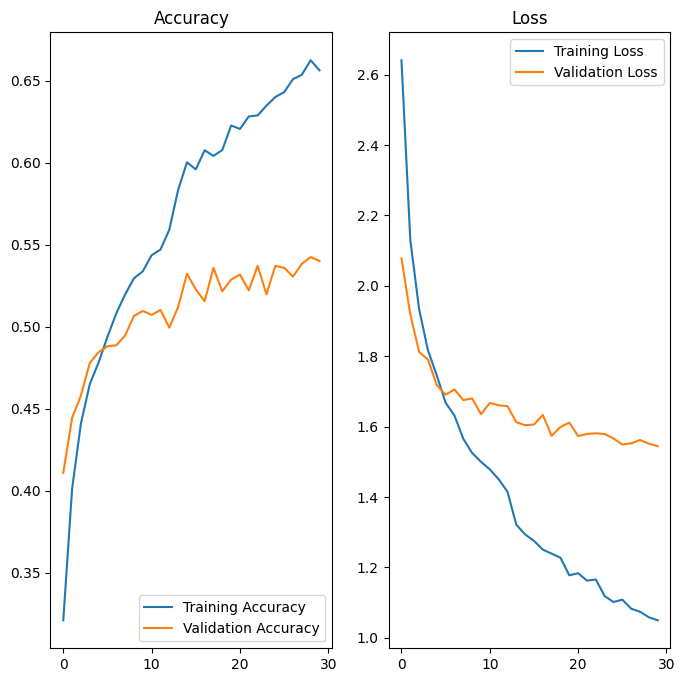

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Accuracy')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import tensorflow as tf # Import tensorflow to use image_dataset_from_directory

# Re-create a dummy dataset instance to get class names
# This is necessary because val_ds (being a _PrefetchDataset) does not retain class_names
dummy_ds_for_class_names = tf.keras.utils.image_dataset_from_directory(
    dataset_path, # dataset_path is available from previous cells
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    color_mode='rgb',
    shuffle=False # No need to shuffle if only getting class names
)
class_names_list = dummy_ds_for_class_names.class_names

# Print the classification report
print(classification_report(true_classes, predicted_classes, target_names=class_names_list))

Found 8363 files belonging to 42 classes.
Using 6691 files for training.
                   precision    recall  f1-score   support

         Alambadi       0.71      0.37      0.49        27
       Amritmahal       0.33      0.36      0.34        14
         Ayrshire       0.69      0.22      0.33        41
            Banni       0.50      0.23      0.32        30
           Bargur       0.83      0.56      0.67        18
        Bhadawari       0.11      0.07      0.08        15
      Brown_Swiss       0.43      0.48      0.45        42
            Dangi       0.57      0.57      0.57         7
            Deoni       0.27      0.36      0.31        11
              Gir       0.67      0.61      0.64        77
         Guernsey       0.71      0.38      0.50        26
         Hallikar       0.47      0.50      0.48        42
          Hariana       0.30      0.22      0.25        32
Holstein_Friesian       0.74      0.44      0.55        73
       Jaffrabadi       0.39      0.47   

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 5, 5, 2048)     │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 42)             │        10,794 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,425,184 (89.36 MB)

 Trainable params: 539,434 (2.06 MB)

 Non-trainable params: 21,806,880 (83.19 MB)

 Optimizer params: 1,078,870 (4.12 MB)

53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step
Found 8363 files belonging to 42 classes.
Using 6691 files for training.


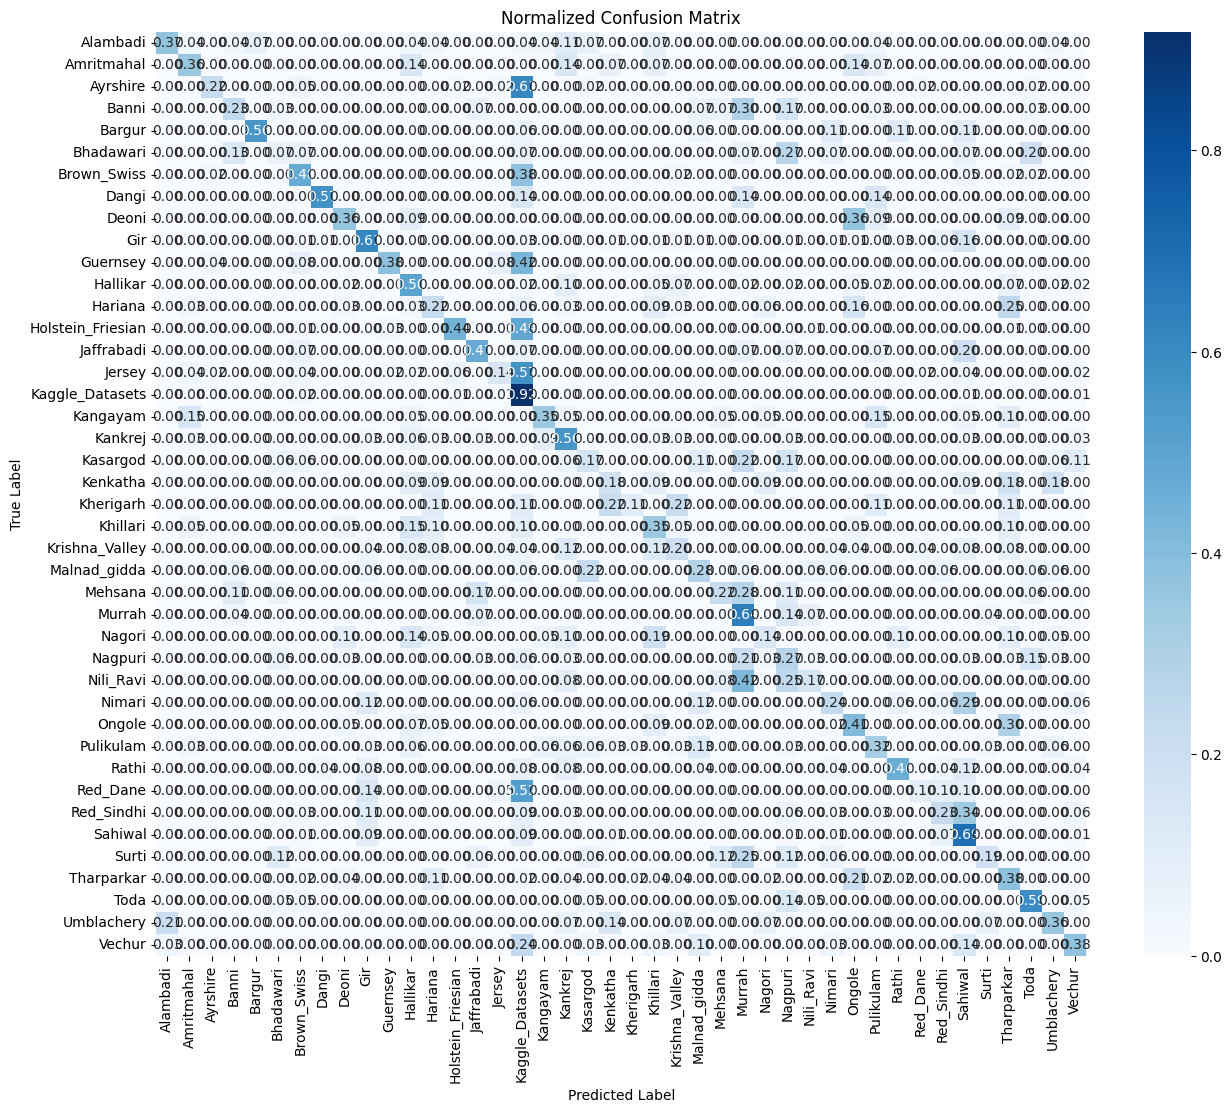

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf # Import tensorflow to use image_dataset_from_directory

# Make predictions on the validation data
predictions = model.predict(val_ds)
predicted_classes = np.argmax(predictions, axis=1)

# Get true labels from validation data
true_classes = []
for _, labels in val_ds:
    true_classes.extend(labels.numpy())
true_classes = np.array(true_classes)

# Re-create a dummy dataset instance to get class names
# This is necessary because val_ds (being a _PrefetchDataset) does not retain class_names
dummy_ds_for_class_names = tf.keras.utils.image_dataset_from_directory(
    dataset_path, # dataset_path is available from previous cells
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    color_mode='rgb',
    shuffle=False # No need to shuffle if only getting class names
)
class_names_list = dummy_ds_for_class_names.class_names

# Compute confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Normalize confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot the normalized confusion matrix
plt.figure(figsize=(15, 12))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names_list, yticklabels=class_names_list)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix')
plt.show()

In [ ]:
import tensorflow as tf
from sklearn.metrics import classification_report
import numpy as np

# Add the definition of dataset_path here as it was not defined in the current execution context
dataset_path = '/content/drive/MyDrive/Indian Cattle'

# Re-create a dummy dataset instance to get class names
# This is necessary because val_ds (being a _PrefetchDataset) does not retain class_names
dummy_ds_for_class_names = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    color_mode='rgb',
    shuffle=False # No need to shuffle if only getting class names
)
class_names_list = dummy_ds_for_class_names.class_names

print(f"Detected {len(class_names_list)} classes: {class_names_list}")

Found 8363 files belonging to 42 classes.
Using 6691 files for training.
Detected 42 classes: ['Alambadi', 'Amritmahal', 'Ayrshire', 'Banni', 'Bargur', 'Bhadawari', 'Brown_Swiss', 'Dangi', 'Deoni', 'Gir', 'Guernsey', 'Hallikar', 'Hariana', 'Holstein_Friesian', 'Jaffrabadi', 'Jersey', 'Kaggle_Datasets', 'Kangayam', 'Kankrej', 'Kasargod', 'Kenkatha', 'Kherigarh', 'Khillari', 'Krishna_Valley', 'Malnad_gidda', 'Mehsana', 'Murrah', 'Nagori', 'Nagpuri', 'Nili_Ravi', 'Nimari', 'Ongole', 'Pulikulam', 'Rathi', 'Red_Dane', 'Red_Sindhi', 'Sahiwal', 'Surti', 'Tharparkar', 'Toda', 'Umblachery', 'Vechur']


In [ ]:
class ClassificationReportCallback(tf.keras.callbacks.Callback):
    def __init__(self, validation_data, class_names):
        super().__init__()
        self.validation_data = validation_data
        self.class_names = class_names

        # Pre-collect true labels once for efficiency
        self.true_classes = []
        for _, labels in validation_data:
            self.true_classes.extend(labels.numpy())
        self.true_classes = np.array(self.true_classes)

    def on_epoch_end(self, epoch, logs=None):
        # Make predictions on the validation data
        predictions = self.model.predict(self.validation_data, verbose=0)
        predicted_classes = np.argmax(predictions, axis=1)

        print(f"\n--- Classification Report for Epoch {epoch + 1} ---")
        print(classification_report(
            self.true_classes,
            predicted_classes,
            target_names=self.class_names,
            zero_division='warn'
        ))
        print("--------------------------------------------------")


In [ ]:
import tensorflow as tf

# Re-define necessary variables from previous cells that were not executed
# Dataset path (change if your path is different)
dataset_path = '/content/drive/MyDrive/Indian Cattle'

# Data Loading
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    color_mode='rgb'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    color_mode='rgb'
)

AUTOTUNE = tf.data.AUTOTUNE
num_classes = len(train_ds.class_names)

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Compile the model (added to fix the ValueError)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0008),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

# Instantiate the custom callback
classification_report_callback = ClassificationReportCallback(val_ds, class_names_list)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, reduce_lr, classification_report_callback]
)

Found 8363 files belonging to 42 classes.
Using 6691 files for training.
Found 8363 files belonging to 42 classes.
Using 1672 files for validation.
Epoch 1/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.2779 - loss: 2.9630
--- Classification Report for Epoch 1 ---
                   precision    recall  f1-score   support

         Alambadi       0.50      0.15      0.23        27
       Amritmahal       0.20      0.07      0.11        14
         Ayrshire       0.35      0.20      0.25        41
            Banni       0.36      0.17      0.23        30
           Bargur       1.00      0.22      0.36        18
        Bhadawari       0.00      0.00      0.00        15
      Brown_Swiss       0.40      0.19      0.26        42
            Dangi       0.67      0.57      0.62         7
            Deoni       0.12      0.09      0.11        11
              Gir       0.37      0.51      0.43        77
         Guernsey       0.57      0.15      0.24        26
         Halli

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3962 - loss: 2.1644
--- Classification Report for Epoch 2 ---
                   precision    recall  f1-score   support

         Alambadi       0.43      0.11      0.18        27
       Amritmahal       0.25      0.07      0.11        14
         Ayrshire       0.50      0.15      0.23        41
            Banni       0.28      0.23      0.25        30
           Bargur       0.90      0.50      0.64        18
        Bhadawari       0.00      0.00      0.00        15
      Brown_Swiss       0.38      0.14      0.21        42
            Dangi       0.25      0.57      0.35         7
            Deoni       0.50      0.09      0.15        11
              Gir       0.55      0.57      0.56        77
         Guernsey       0.50      0.19      0.28        26
         Hallikar       0.33      0.48      0.39        42
          Hariana       0.26      0.34      0.29        32
Holstein_Friesian       0.60      0.37      0.46       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.4419 - loss: 1.9216
--- Classification Report for Epoch 3 ---
                   precision    recall  f1-score   support

         Alambadi       0.71      0.19      0.29        27
       Amritmahal       0.15      0.14      0.15        14
         Ayrshire       0.34      0.27      0.30        41
            Banni       0.24      0.17      0.20        30
           Bargur       0.88      0.39      0.54        18
        Bhadawari       0.12      0.07      0.09        15
      Brown_Swiss       0.37      0.17      0.23        42
            Dangi       0.43      0.43      0.43         7
            Deoni       0.14      0.09      0.11        11
              Gir       0.54      0.55      0.54        77
         Guernsey       0.30      0.12      0.17        26
         Hallikar       0.32      0.31      0.31        42
          Hariana       0.41      0.22      0.29        32
Holstein_Friesian       0.52      0.37      0.43       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.4771 - loss: 1.8257
--- Classification Report for Epoch 4 ---
                   precision    recall  f1-score   support

         Alambadi       0.80      0.15      0.25        27
       Amritmahal       0.14      0.07      0.10        14
         Ayrshire       0.33      0.20      0.25        41
            Banni       0.38      0.10      0.16        30
           Bargur       0.86      0.67      0.75        18
        Bhadawari       0.00      0.00      0.00        15
      Brown_Swiss       0.36      0.21      0.27        42
            Dangi       0.57      0.57      0.57         7
            Deoni       0.25      0.09      0.13        11
              Gir       0.52      0.56      0.54        77
         Guernsey       0.33      0.08      0.12        26
         Hallikar       0.17      0.19      0.18        42
          Hariana       0.50      0.12      0.20        32
Holstein_Friesian       0.68      0.26      0.38       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5403 - loss: 1.4894
--- Classification Report for Epoch 10 ---
                   precision    recall  f1-score   support

         Alambadi       0.55      0.44      0.49        27
       Amritmahal       0.27      0.21      0.24        14
         Ayrshire       0.78      0.17      0.28        41
            Banni       0.30      0.33      0.32        30
           Bargur       0.85      0.61      0.71        18
        Bhadawari       0.07      0.07      0.07        15
      Brown_Swiss       0.40      0.19      0.26        42
            Dangi       0.50      0.57      0.53         7
            Deoni       0.50      0.36      0.42        11
              Gir       0.41      0.71      0.52        77
         Guernsey       0.67      0.08      0.14        26
         Hallikar       0.34      0.48      0.40        42
          Hariana       0.38      0.16      0.22        32
Holstein_Friesian       0.72      0.38      0.50      